In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
# os.environ["JAX_PLATFORM_NAME"] = "cpu"  # force CPU backend in this notebook


In [2]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import jax
from netket.operator.fermion import create as cdag
from netket.operator.fermion import destroy as c
from netket.operator.fermion import number as nc
print(jax.devices())


∣NK⟩ Tip: You can plot data with JsonLog.data['Energy'][:-30].plot().

[CudaDevice(id=0)]


In [3]:
#single particle parameters

t1 = 1.0
t2 = -1/(4 * np.cos(0.65)) #-1/(4 * np.cos(0.65)) #0.15
phi = 0.65 #np.pi / 2
m = 0.

#parameters from DMRG paper by Zalatel et al on Haldane model: t1 = 1.0, t2 = -1/(4 * np.cos(0.65)), phi = 0.65

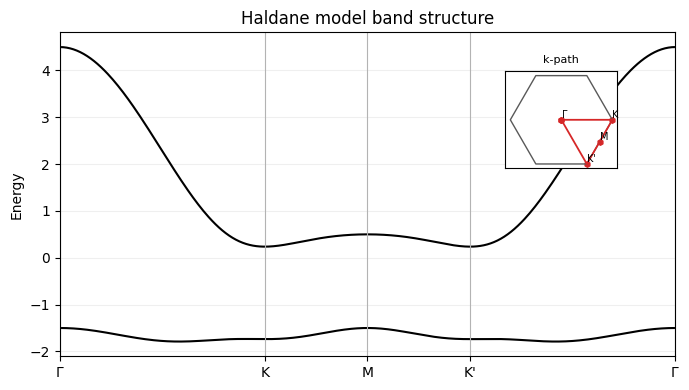

K point used = [4.18879020, 0.00000000]
Berry curvature at K (lower band): 0.38452690
Trace of quantum metric at K (lower band): 0.38452690
Estimated Chern number (lower band) = 1.0000000000
Estimated quantum weight (lower band) = 1.0664954341


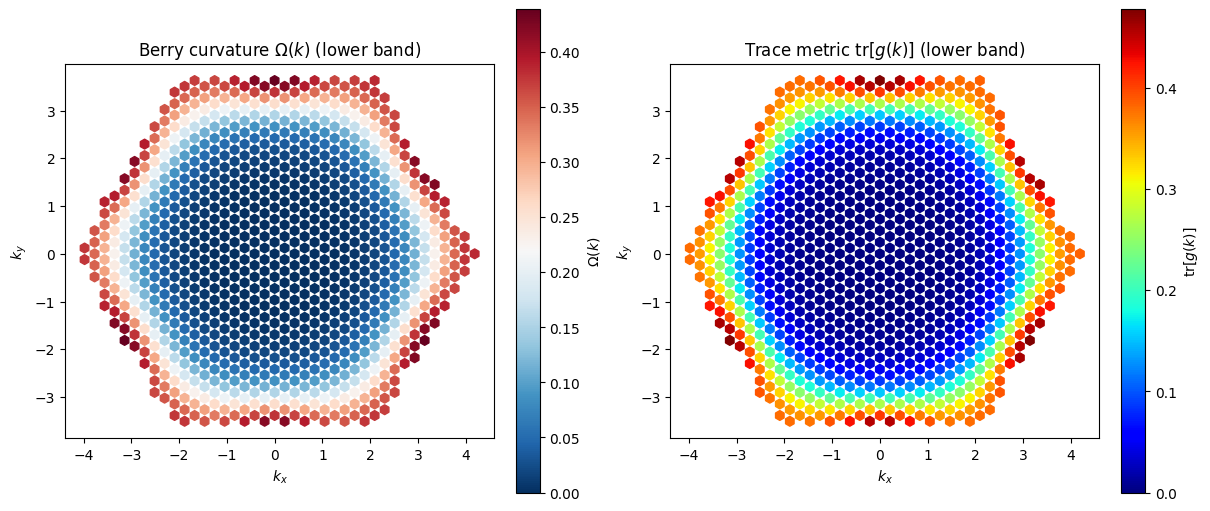

In [4]:
#single particle properties

import matplotlib.pyplot as plt

from aidan_custom.geometry import (
    ANNN_VECTORS,
    DELTA_VECTORS,
    PRIMITIVE_A1,
    PRIMITIVE_A2,
    SUBLATTICE_A_OFFSET,
    SUBLATTICE_B_OFFSET,
    first_bz_hexagon_vertices,
    fold_to_shortest_k,
    high_symmetry_points,
    k_path_gamma_k_m_kp_gamma,
    reciprocal_vectors,
    sample_shortest_representative_bz,
)
from aidan_custom.bandstructure import (
    berry_curvature_and_metric_trace_at_k,
    eigenvalues_at_k,
)

# Keep the same names used throughout the notebook.
a1 = PRIMITIVE_A1.copy()
a2 = PRIMITIVE_A2.copy()
rA = SUBLATTICE_A_OFFSET.copy()
rB = SUBLATTICE_B_OFFSET.copy()
delta_vectors = DELTA_VECTORS
annn_vectors = ANNN_VECTORS

b1, b2 = reciprocal_vectors(a1, a2)

# Band structure along high-symmetry path (same orientation used everywhere)
k_points, x, x_nodes, labels = k_path_gamma_k_m_kp_gamma(120, b1, b2)
bands = np.array(
    [eigenvalues_at_k(kx, ky, t1=t1, t2=t2, phi=phi, m=m) for kx, ky in k_points]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, bands[:, 0], color="black")
ax.plot(x, bands[:, 1], color="black")
for xn in x_nodes:
    ax.axvline(xn, color="0.7", lw=0.8)
ax.set_xticks(x_nodes)
ax.set_xticklabels(labels)
ax.set_xlim(x[0], x[-1])
ax.set_ylabel("Energy")
ax.set_title("Haldane model band structure")
ax.grid(axis="y", alpha=0.2)

# Inset: k-space path Γ→K→M→K'→Γ with first-BZ boundary
gamma, k_node, m_node, kp_node = high_symmetry_points(b1, b2)
path_nodes = np.array([gamma, k_node, m_node, kp_node, gamma])
bz_hex = first_bz_hexagon_vertices(b1, b2)
bz_hex_closed = np.vstack([bz_hex, bz_hex[0]])

ax_in = ax.inset_axes([0.69, 0.58, 0.25, 0.30])
ax_in.plot(bz_hex_closed[:, 0], bz_hex_closed[:, 1], color="0.35", lw=1.0)
ax_in.plot(path_nodes[:, 0], path_nodes[:, 1], color="tab:red", lw=1.3)
ax_in.scatter(path_nodes[:, 0], path_nodes[:, 1], s=16, c="tab:red", marker="h")
for point, label in zip(path_nodes[:-1], labels[:-1]):
    ax_in.text(point[0], point[1], label, fontsize=7, ha="left", va="bottom")
ax_in.set_xticks([])
ax_in.set_yticks([])
ax_in.set_aspect("equal", "box")
ax_in.set_title("k-path", fontsize=8)
plt.tight_layout()
plt.show()

# Example QGT-derived values at K
_, kK, _, _ = high_symmetry_points(b1, b2)
omega_K, tr_g_K = berry_curvature_and_metric_trace_at_k(
    kK[0], kK[1], t1=t1, t2=t2, phi=phi, m=m, band="lower"
)
print(f"K point used = [{kK[0]:.8f}, {kK[1]:.8f}]")
print(f"Berry curvature at K (lower band): {omega_K:.8f}")
print(f"Trace of quantum metric at K (lower band): {tr_g_K:.8f}")

# Scatter plots over first BZ by shortest-representative map
# (independent local override for this cell)
Lx_bz_plot = 30
Ly_bz_plot = Lx_bz_plot

# Use all mesh points (N_k = Lx_bz_plot*Ly_bz_plot) for BZ integrals.
k_bz_all = sample_shortest_representative_bz(
    Lx_bz_plot, Ly_bz_plot, b1, b2, unique=False
)
if k_bz_all.size == 0:
    raise ValueError("No BZ points sampled. Increase Lx_bz_plot/Ly_bz_plot.")

berry_all = np.empty(k_bz_all.shape[0], dtype=float)
trg_all = np.empty(k_bz_all.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz_all):
    omega, trg = berry_curvature_and_metric_trace_at_k(
        kx,
        ky,
        t1=t1,
        t2=t2,
        phi=phi,
        m=m,
        band="lower",
    )
    berry_all[i] = omega
    trg_all[i] = trg

# First-BZ area and quadrature weights for uniform mesh of this system size.
area_bz = abs(b1[0] * b2[1] - b1[1] * b2[0])
n_k = Lx_bz_plot * Ly_bz_plot
dk_area = area_bz / n_k
chern_number = (dk_area / (2.0 * np.pi)) * np.sum(berry_all)
quantum_weight = dk_area * np.sum(trg_all) / (2 * np.pi)
print(f"Estimated Chern number (lower band) = {chern_number:.10f}")
print(f"Estimated quantum weight (lower band) = {quantum_weight:.10f}")

# Unique representatives for cleaner scatter visualization.
k_bz = sample_shortest_representative_bz(Lx_bz_plot, Ly_bz_plot, b1, b2, unique=True)
berry_bz = np.empty(k_bz.shape[0], dtype=float)
trg_bz = np.empty(k_bz.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz):
    omega, trg = berry_curvature_and_metric_trace_at_k(
        kx,
        ky,
        t1=t1,
        t2=t2,
        phi=phi,
        m=m,
        band="lower",
    )
    berry_bz[i] = omega
    trg_bz[i] = trg

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
marker_size = 50
sc0 = axes[0].scatter(
    k_bz[:, 0],
    k_bz[:, 1],
    s=marker_size,
    c=berry_bz,
    cmap="RdBu_r",
    marker="h",
)
axes[0].set_title(r"Berry curvature $\Omega(k)$ (lower band)")
axes[0].set_xlabel(r"$k_x$")
axes[0].set_ylabel(r"$k_y$")
axes[0].set_aspect("equal", "box")
fig.colorbar(sc0, ax=axes[0], label=r"$\Omega(k)$")

sc1 = axes[1].scatter(
    k_bz[:, 0],
    k_bz[:, 1],
    s=marker_size,
    c=trg_bz,
    cmap="jet",
    marker="h",
)
axes[1].set_title(r"Trace metric $\mathrm{tr}[g(k)]$ (lower band)")
axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")
axes[1].set_aspect("equal", "box")
fig.colorbar(sc1, ax=axes[1], label=r"$\mathrm{tr}[g(k)]$")
plt.show()


In [10]:
# many-body system parameters
# Haldane model parameters
Lx, Ly = 3, 3
V1 = 0.0
n_fermions = 3

from aidan_custom.haldane_model import build_haldane_hamiltonian
from aidan_custom.models import LogSlaterDeterminant, LogSlaterJastrow

graph, hi, ham = build_haldane_hamiltonian(
    Lx=Lx,
    Ly=Ly,
    t1=t1,
    t2=t2,
    phi=phi,
    m=m,
    V1=V1,
    n_fermions=n_fermions,
)

assert n_fermions <= graph.n_nodes
print(f"n_sites={graph.n_nodes}, n_fermions={hi.n_fermions}")
print(f"hilbert={hi}")
print(f"V1={V1}")
print(f"max_conn_size={ham.max_conn_size}")


n_sites=18, n_fermions=3
hilbert=SpinOrbitalFermions(n_orbitals=18, n_fermions=3)
V1=0.0
max_conn_size=27


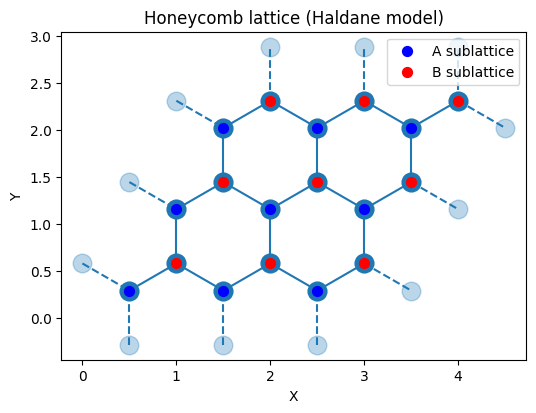

In [11]:
import matplotlib.pyplot as plt
# Visualize the lattice using NetKet built-in drawing
ax = graph.draw(
    distance_order=1,
    draw_text=False,
    draw_basis_vectors=False,
    draw_unit_cell=False,
    node_size=180,
    figsize=(6, 6),
    show=False
)
# Highlight the two honeycomb sublattices (A/B)
coords = graph.basis_coords
positions = graph.positions
a_sites = coords[:, 2] == 0
b_sites = coords[:, 2] == 1
ax.scatter(
    positions[a_sites, 0],
    positions[a_sites, 1],
    s=50,
    c="blue",
    label="A sublattice",
    zorder=5,
)
ax.scatter(
    positions[b_sites, 0],
    positions[b_sites, 1],
    s=50,
    c="red",
    label="B sublattice",
    zorder=5,
)
ax.legend(loc="upper right")
ax.set_title("Honeycomb lattice (Haldane model)")
plt.show()


In [12]:
from aidan_custom.models import (
    LogSlaterDeterminant,
    LogSlaterJastrow,
    LogSlaterSpatialViT,
    make_translation_equivariant_pair_data_from_graph,
)
from aidan_custom.optimization import (
    exact_reference_ground_state_energy,
    log_optimization_diagnostics,
)

Sampling dictionary:

n_chains: number of independent Markov chains evolved in parallel (global across devices). See metropolis.py (line 256) and base.py (line 153).

sweep_size: number of Metropolis proposal/accept steps done before recording one next sample in each chain (subsampling interval). See metropolis.py (line 263), and loop at metropolis.py (line 462).

n_samples: total number of kept samples returned by MCState.sample(...) across all chains. Internally, chain length is ceil(n_samples / n_chains), so NetKet may round up to a multiple of n_chains. See state.py (line 58) and state.py (line 67).

n_discard_per_chain: burn-in samples discarded at the beginning of each chain before kept samples are drawn. See state.py (line 442) and discard call at state.py (line 557).

## Spatial ViT Architecture (Exactly As Implemented)

This describes the **ViT factor** in `LogSlaterSpatialViT`, i.e. $\log\Psi_{\mathrm{ViT}}$, exactly as implemented in `aidan_custom/models.py`.

The full ansatz used in `LogSlaterSpatialViT` is

$$
\log\Psi(n)=\log\Psi_{\mathrm{Slater}}(n)+\log\Psi_{\mathrm{ViT}}(n).
$$

### 1) Input And Site Embedding

For spinless occupations $(n\in\{0,1\}^{N_s})$, each site is a token. Before embedding we remap occupancy to Ising-style values:

$$
s_i = egin{cases}
+1 & n_i > 0 \\
-1 & n_i \le 0
\end{cases}
$$

A shared dense map then embeds each scalar $s_i$ into $(d\equiv d_{\text{model}})$:

$$
\mathbf{x}^{(0)}_i = W_{\mathrm{emb}}\, s_i + \mathbf{b}_{\mathrm{emb}},
\qquad W_{\mathrm{emb}}\in\mathbb{R}^{1\times d},\; \mathbf{b}_{\mathrm{emb}}\in\mathbb{R}^{d}.
$$

### 2) Translation-Equivariant Pair Classes (Minimum-Image)

Using site positions $(\mathbf{r}_i)$, lattice basis vectors $((\mathbf{a}_1,\mathbf{a}_2))$, extents $((L_x,L_y))$, and periodic flags, translations are

$$
\mathbf{t}_{m_1,m_2}=(m_1L_x)\mathbf{a}_1 + (m_2L_y)\mathbf{a}_2,
$$

with $(m_\mu\in\{-1,0,1\})$ if periodic in direction $(\mu)$, else $(m_\mu=0)$.

For each pair $(i,j)$, the displacement used by attention is the minimum-image vector

$$
\Delta\mathbf{r}_{ij} = \arg\min_{\mathbf{t}}\left\| (\mathbf{r}_i-\mathbf{r}_j)+\mathbf{t} \right\|_2.
$$

These vectors are rounded (default 12 decimals), uniqued into classes $c\in\{1,\dots,K\}$, and mapped by

$$
C_{ij}\in\{1,\dots,K\},\qquad d_c=\|\Delta\mathbf{r}_c\|_2.
$$

So each pair $(i,j)$ references a class index $C_{ij}$, and each class has a fixed distance $d_c$.

### 3) One Spatial Attention Layer (Factored Kernel)

For an input $\mathbf{x}\in\mathbb{R}^{B\times N_s\times d}$:

1. **Value projection only** (no query/key projections):

$$
\mathbf{v}_i = W_V\mathbf{x}_i + \mathbf{b}_V,
\qquad W_V\in\mathbb{R}^{d\times d},\;\mathbf{b}_V\in\mathbb{R}^{d}.
$$

2. Split into $H$ heads, $d_h=d/H$: $\mathbf{v}_i\to\mathbf{v}_i^{(a)}\in\mathbb{R}^{d_h}$.

3. Learned per-head/class amplitudes $\alpha_{a,c}$ and per-head length scales $\xi_a$:

$$
\xi_a = \operatorname{softplus}(\rho_a)+\epsilon_\xi,
$$

where $\rho_a$ is `raw_xi`, $\epsilon_\xi=\texttt{vit\_xi\_epsilon}$, and default initialization sets $\xi_a\approx1.5$ for all heads.

4. Unnormalized exponential envelope:

$$
\widehat{E}_{a,c}=\exp\!\left(-\frac{d_c}{\xi_a}\right).
$$

5. Pairwise normalization (for each head $a$ and destination site $i$):

$$
Z_{a,i}=\sum_{j'=1}^{N_s}\widehat{E}_{a,\,C_{ij'}},
\qquad
E_{a,ij}=\frac{\widehat{E}_{a,\,C_{ij}}}{Z_{a,i}}.
$$

6. Pair kernel with learned amplitude:

$$
A_{a,ij}=\alpha_{a,\,C_{ij}}\,E_{a,ij}.
$$

7. Headwise aggregation (no query-key softmax):

$$
\tilde{\mathbf{v}}^{(a)}_i = \sum_{j=1}^{N_s} A_{a,ij}\,\mathbf{v}^{(a)}_j.
$$

8. Concatenate heads and apply output projection:

$$
\tilde{\mathbf{v}}_i = \operatorname{concat}_a\tilde{\mathbf{v}}^{(a)}_i\in\mathbb{R}^d,
\qquad
\mathbf{y}_i = W_O\tilde{\mathbf{v}}_i + \mathbf{b}_O,
$$

with $W_O\in\mathbb{R}^{d\times d}$, $\mathbf{b}_O\in\mathbb{R}^d$.

### 4) Encoder Block (Pre-LN, Residual, FFN)

Each block applies

$$
\mathbf{y} = \mathbf{x} + \operatorname{Attn}(\operatorname{LN}_1(\mathbf{x})),
$$

$$
\mathbf{z} = \mathbf{y} + \operatorname{FF}(\operatorname{LN}_2(\mathbf{y})),
$$

with feature-wise FFN

$$
\operatorname{FF}(\mathbf{u}) = W_2\,\operatorname{GELU}(W_1\mathbf{u}+\mathbf{b}_1)+\mathbf{b}_2,
$$

$$
W_1\in\mathbb{R}^{d\times(rd)},\quad W_2\in\mathbb{R}^{(rd)\times d},\quad r=\texttt{vit\_mlp\_hidden\_factor}.
$$

Stacking $L=\texttt{vit\_num\_layers}$ such blocks gives $\mathbf{x}^{(L)}$.

### 5) Complex Output Head For $\log\Psi_{\mathrm{ViT}}$

Pool over sites and normalize:

$$
\mathbf{z}=\operatorname{LN}_{\mathrm{out}}\!\left(\sum_{i=1}^{N_s} \mathbf{x}^{(L)}_i\right)\in\mathbb{R}^d.
$$

Real and imaginary branches:

$$
\mathbf{r}=\operatorname{LN}_{\Re}(W_{\Re}\mathbf{z}+\mathbf{b}_{\Re})\in\mathbb{R}^{d_o},
\qquad
\mathbf{u}=\operatorname{LN}_{\Im}(W_{\Im}\mathbf{z}+\mathbf{b}_{\Im})\in\mathbb{R}^{d_o},
$$

where $d_o=\texttt{vit\_output\_hidden\_dim}$ (or $d$ if `None`).

Finally,

$$
\log\Psi_{\mathrm{ViT}}(n)=\sum_{k=1}^{d_o}\log\cosh\!\big(r_k+i\,u_k\big).
$$

### 6) Dtype/Complexity Convention

- All ViT internal parameters and activations are real (`vit_param_dtype`, currently float64 by default).
- Complex structure appears only at the final combination $\mathbf{r}+i\mathbf{u}$ in the output head.
- There are no query/key projections and no query-key softmax in this implementation; attention weights are $A_{a,ij}=\alpha_{a,C_{ij}}\,\widehat{E}_{a,C_{ij}}/\sum_{j'}\widehat{E}_{a,C_{ij'}}$ with $\widehat{E}_{a,c}=\exp(-d_c/\xi_a)$.


In [ ]:
import optax

model_type = "slater_spatial_vit"  # options: "slater", "slater_jastrow", "slater_spatial_vit"

# Optimization controls
n_iter = 200
n_samples = 1024 * 4
n_discard_per_chain = 64
sweep_size = 64  # number of MC move proposals between sample measurements
n_chains = 16

# Spatial-ViT controls (used only for model_type == "slater_spatial_vit")
vit_num_layers = 2 #Number of stacked spatial transformer encoder blocks.
vit_d_model = 32 #Token feature dimension d throughout the ViT.
vit_n_heads = 4 #Number of attention heads; each head has size d_head = d/n_heads
vit_mlp_hidden_factor = 4 #Expansion factor r in each block's FFN, so hidden is size r * d
vit_output_hidden_dim = 32 #Hidden dimension d_h in the final real/imag output dense layers
vit_xi_epsilon = 1.0e-6 #small positive stabilizer added to the learned \xi in the spatial envelope \xi

from aidan_custom.models import (
    LogSlaterDeterminant,
    LogSlaterJastrow,
    LogSlaterSpatialViT,
    make_translation_equivariant_pair_data_from_graph,
)
from aidan_custom.optimization import (
    exact_reference_ground_state_energy,
    log_optimization_diagnostics,
)

sampler = nk.sampler.MetropolisFermionHop(
    hi,
    graph=graph,
    n_chains=n_chains,
    sweep_size=sweep_size,
)

if model_type == "slater":
    model = LogSlaterDeterminant(hi, param_dtype=complex)
elif model_type == "slater_jastrow":
    model = LogSlaterJastrow(hi, param_dtype=complex, jastrow_param_dtype=complex)
elif model_type == "slater_spatial_vit":
    pair_classes, pair_distances, pair_vectors = make_translation_equivariant_pair_data_from_graph(graph)
    print(
        f"Spatial pair classes: {pair_distances.size}; "
        f"pair_classes shape={pair_classes.shape}; pair_vectors shape={pair_vectors.shape}"
    )

    # Flax modules are hashed in NetKet internals, so static attributes must be hashable.
    pair_classes_hashable = tuple(tuple(int(v) for v in row) for row in pair_classes)
    pair_distances_hashable = tuple(float(v) for v in pair_distances)

    model = LogSlaterSpatialViT(
        hilbert=hi,
        num_layers=vit_num_layers,
        d_model=vit_d_model,
        n_heads=vit_n_heads,
        pair_classes=pair_classes_hashable,
        pair_distances=pair_distances_hashable,
        # VMC_SR currently requires homogeneous parameter dtypes across the model tree.
        slater_param_dtype=np.float64,
        mlp_hidden_factor=vit_mlp_hidden_factor,
        output_hidden_dim=vit_output_hidden_dim,
        xi_epsilon=vit_xi_epsilon,
    )
else:
    raise ValueError(f"Unknown model_type={model_type!r}")

vstate = nk.vqs.MCState(
    sampler,
    model,
    n_samples=n_samples,
    n_discard_per_chain=n_discard_per_chain,
)
optimizer = nk.optimizer.Sgd(learning_rate=optax.linear_schedule(0.05, 0.005, n_iter))
driver = nk.driver.VMC_SR(
    ham,
    optimizer,
    variational_state=vstate,
    diag_shift=0.01,
    mode="complex",
)
log = nk.logging.RuntimeLog()
driver.run(n_iter=n_iter, out=log, callback=log_optimization_diagnostics)


Automatic SR implementation choice:  QGT


  0%|          | 0/200 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['acceptance', 'Energy', 'UpdateNormL2'],)

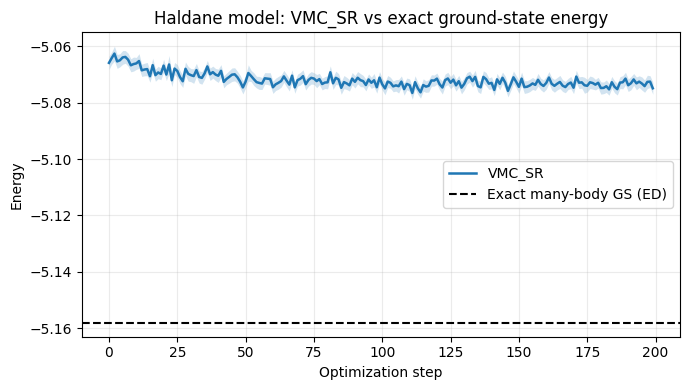

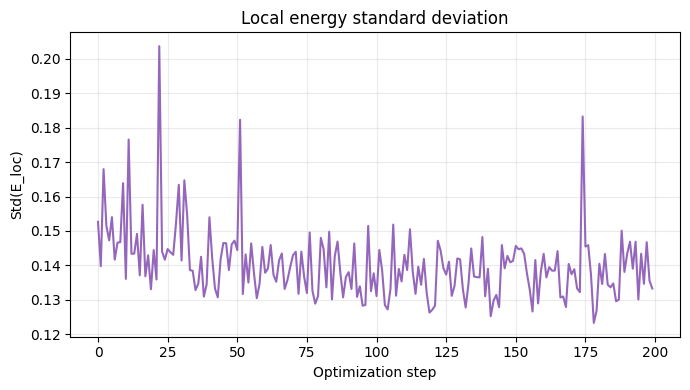

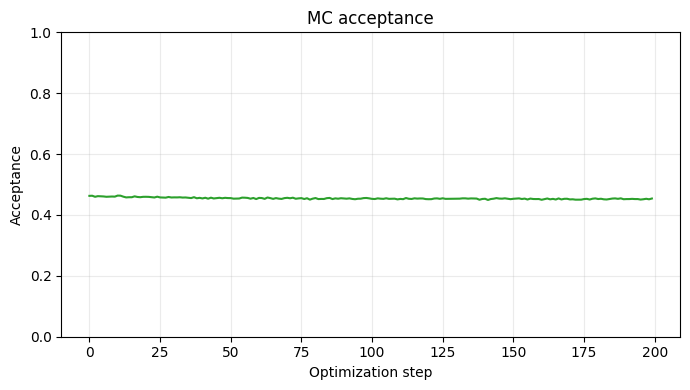

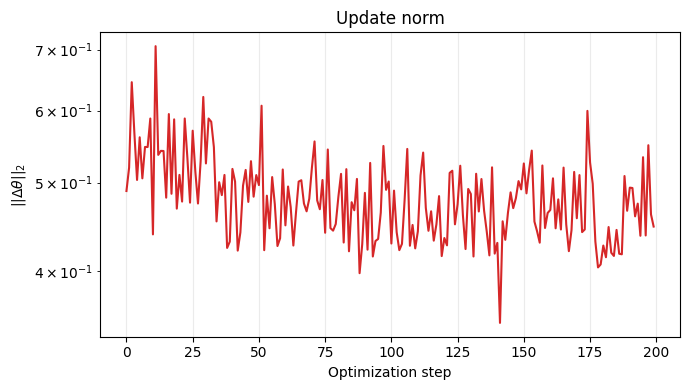

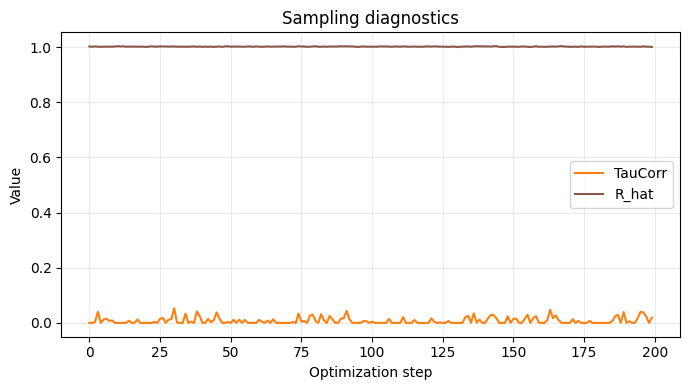

Exact ground-state reference [ED (interacting)] = -5.1581151039
Final VMC_SR energy (real part) = -5.0748893242
Final error (VMC - reference) = 0.0832257797
Final MC acceptance = 0.454015
Final update norm ||dtheta||_2 = 4.473639e-01
Final local-energy std dev = 0.1332983012


In [17]:
#plot optimization data

import math

energy_history = log.data["Energy"]
iters = np.asarray(energy_history.iters)
energy_mean = np.asarray(energy_history["Mean"])
energy_sigma = np.asarray(energy_history["Sigma"])
energy_variance = np.asarray(energy_history["Variance"])

energy_std_local = np.sqrt(np.maximum(np.real(energy_variance), 0.0))
energy_tau = np.asarray(energy_history["TauCorr"])
energy_rhat = np.asarray(energy_history["R_hat"])

acceptance_history = log.data.get("acceptance", None)
acceptance_iters = np.asarray(acceptance_history.iters)
acceptance_values = np.asarray(acceptance_history)

update_norm_history = log.data.get("UpdateNormL2", None)
update_norm_iters = np.asarray(update_norm_history.iters) if update_norm_history is not None else None
update_norm_values = np.asarray(update_norm_history) if update_norm_history is not None else None

# Exact reference: skip if C(n_sites, n_fermions) exceeds cutoff.
reference_dim_cutoff = 100_000
hilbert_dim_comb = math.comb(int(hi.n_orbitals), int(hi.n_fermions))
compute_reference = hilbert_dim_comb <= reference_dim_cutoff

if compute_reference:
    e_ref, e_ref_plot_label, e_ref_method = exact_reference_ground_state_energy(
        hamiltonian=ham,
        Lx=Lx,
        Ly=Ly,
        n_fermions=int(hi.n_fermions),
        t1=t1,
        t2=t2,
        phi=phi,
        m=m,
        V1=V1,
    )
else:
    e_ref = None
    e_ref_plot_label = None
    e_ref_method = (
        f"skipped (C(n_sites,n_fermions)={hilbert_dim_comb} > {reference_dim_cutoff})"
    )

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, energy_mean.real, lw=1.8, color="tab:blue", label="VMC_SR")
ax.fill_between(
    iters,
    energy_mean.real - energy_sigma,
    energy_mean.real + energy_sigma,
    color="tab:blue",
    alpha=0.2,
    linewidth=0,
)
if e_ref is not None:
    ax.axhline(e_ref, color="black", ls="--", lw=1.5, label=e_ref_plot_label)
    ax.set_title("Haldane model: VMC_SR vs exact ground-state energy")
else:
    ax.set_title("Haldane model: VMC_SR energy")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Energy")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, energy_std_local, color="tab:purple", lw=1.5)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Std(E_loc)")
ax.set_title("Local energy standard deviation")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
if acceptance_values is not None:
    ax.plot(acceptance_iters, acceptance_values, color="tab:green", lw=1.5)
    ax.set_ylim(0.0, 1.0)
else:
    ax.text(0.5, 0.5, "Acceptance not available", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Acceptance")
ax.set_title("MC acceptance")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
if update_norm_values is not None:
    ax.plot(update_norm_iters, update_norm_values, color="tab:red", lw=1.5)
    ax.set_yscale("log")
else:
    ax.text(0.5, 0.5, "Update norm not available", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Optimization step")
ax.set_ylabel(r"||$\Delta\theta$||$_2$")
ax.set_title("Update norm")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
if energy_tau is not None:
    ax.plot(iters, energy_tau, color="tab:orange", lw=1.5, label="TauCorr")
    if energy_rhat is not None:
        ax.plot(iters, energy_rhat, color="tab:brown", lw=1.5, label="R_hat")
        ax.legend()
    ax.set_title("Sampling diagnostics")
else:
    ax.text(0.5, 0.5, "No extra diagnostics available", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Sampling diagnostics")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Value")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

if e_ref is not None:
    print(f"Exact ground-state reference [{e_ref_method}] = {e_ref:.10f}")
    print(f"Final VMC_SR energy (real part) = {energy_mean.real[-1]:.10f}")
    print(f"Final error (VMC - reference) = {energy_mean.real[-1] - e_ref:.10f}")
else:
    print(f"Exact ground-state reference [{e_ref_method}]")
    print(f"Final VMC_SR energy (real part) = {energy_mean.real[-1]:.10f}")
if acceptance_values is not None:
    print(f"Final MC acceptance = {float(acceptance_values[-1]):.6f}")
if update_norm_values is not None:
    print(f"Final update norm ||dtheta||_2 = {float(update_norm_values[-1]):.6e}")
print(f"Final local-energy std dev = {float(energy_std_local[-1]):.10f}")


In [ ]:
# Exact ground-state reference [ED (interacting)] = -4.0109918949
# Final VMC_SR energy (real part) = -4.0111210021
# Final error (VMC - reference) = -0.0001291072
# Final MC acceptance = 0.521704
# Final update norm ||dtheta||_2 = 1.355469e-02
# Final local-energy std dev = 0.0057236713

In [18]:
# Fresh post-training sampling from the optimized state (not cached optimizer samples)
obs_n_samples = max(4096 * 10, vstate.n_samples)
obs_n_discard_per_chain = max(64, vstate.n_discard_per_chain)
vstate.reset()

samples_obs = np.asarray(vstate.sample(n_samples=obs_n_samples, n_discard_per_chain=obs_n_discard_per_chain)).reshape(-1, hi.size).astype(float)

n_samples_obs = samples_obs.shape[0]
n_sites_obs = samples_obs.shape[1]
positions_obs = np.asarray(graph.positions, dtype=float)
obs_sampling_run = int(globals().get("obs_sampling_run", 0)) + 1

print(
    f"Post-training sampling run {obs_sampling_run}: {n_samples_obs} total samples "
    f"(single batch of {obs_n_samples}), "
    f"discard_per_chain={obs_n_discard_per_chain}"
)


Post-training sampling run 2: 40960 total samples (single batch of 40960), discard_per_chain=64


Using post-training samples from run 2 (n=40960)


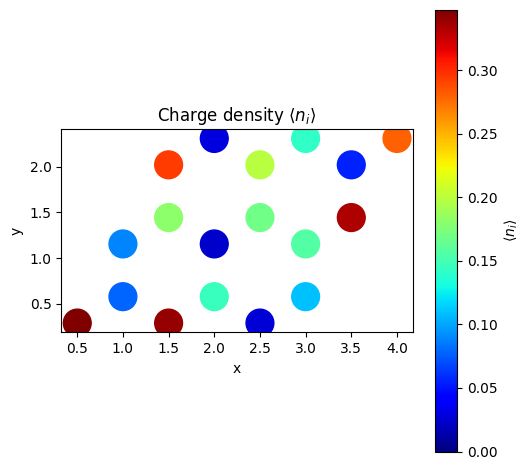

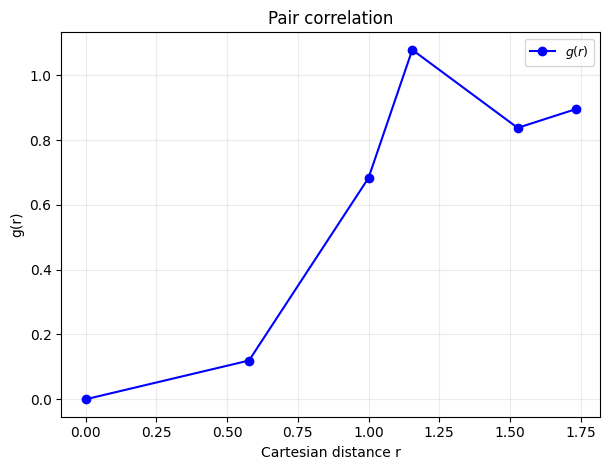

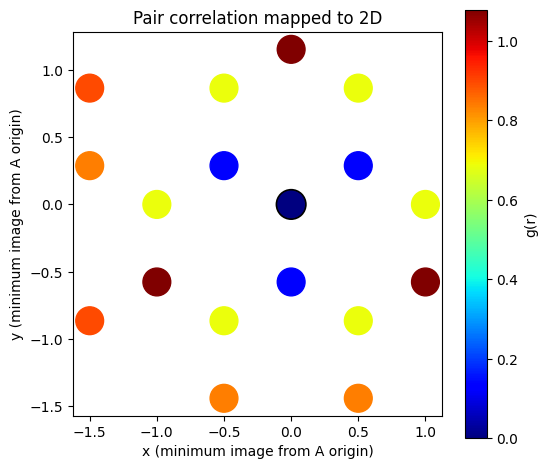

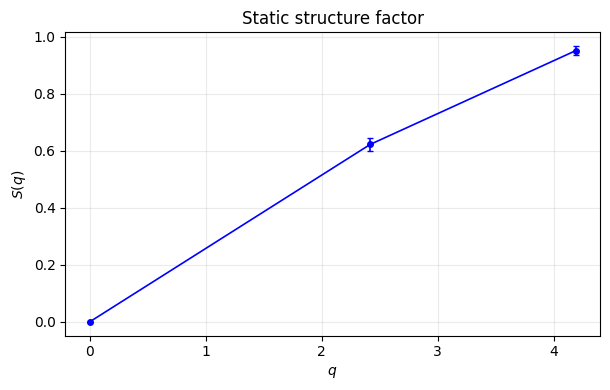

In [19]:
# Post-training observables from MC samples of the optimized wavefunction
# NetKet provides generic expectation tools, but no dedicated built-in helper
# for fermionic pair-correlation / structure-factor post-processing on samples.
import numpy as np
import matplotlib.pyplot as plt

from aidan_custom.observables import (
    map_radial_g_to_minimum_image_2d,
    pair_correlation_cartesian,
    radial_average_structure_factor,
    static_structure_factor,
)

if "samples_obs" not in globals():
    raise RuntimeError("Run the post-training sampling cell before this plotting cell.")

samples = samples_obs
n_samples = int(n_samples_obs)
n_sites = int(n_sites_obs)
positions = positions_obs
print(f"Using post-training samples from run {obs_sampling_run} (n={n_samples})")

basis_vectors = np.asarray(graph.basis_vectors, dtype=float)
pc_data = pair_correlation_cartesian(
    samples=samples,
    positions=positions,
    basis_vectors=basis_vectors,
    pbc=np.asarray(graph.pbc, dtype=bool),
    Lx=Lx,
    Ly=Ly,
    n_fermions=n_fermions,
)

charge_density = pc_data["charge_density"]
corr_matrix = pc_data["corr_matrix"]
dist_matrix = pc_data["dist_matrix"]
translations = pc_data["translations"]
r_values_plot = pc_data["r_values_plot"]
g_r_plot = pc_data["g_r_plot"]

rel_min, g_site, origin_idx, r_site = map_radial_g_to_minimum_image_2d(
    positions=positions,
    basis_coords=np.asarray(graph.basis_coords),
    translations=translations,
    r_values_plot=r_values_plot,
    g_r_plot=g_r_plot,
)

q_list, s_q = static_structure_factor(
    samples=samples,
    positions=positions,
    basis_vectors=basis_vectors,
    Lx=Lx,
    Ly=Ly,
    n_fermions=n_fermions,
)

q_shell_unique, s_q_abs, s_q_abs_err, q_abs, s_q_plot = radial_average_structure_factor(
    q_list,
    s_q,
    set_q0_to_zero=True,
)

fig_charge, ax_charge = plt.subplots(figsize=(5.4, 4.8))
sc0 = ax_charge.scatter(
    positions[:, 0],
    positions[:, 1],
    c=charge_density,
    s=400,
    cmap="jet",
    marker="o",
    clim=(0, np.amax(charge_density)),
)
ax_charge.set_title(r"Charge density $\langle n_i \rangle$")
ax_charge.set_xlabel("x")
ax_charge.set_ylabel("y")
ax_charge.set_aspect("equal", "box")
fig_charge.colorbar(sc0, ax=ax_charge, label=r"$\langle n_i \rangle$")
plt.tight_layout()
plt.show()

fig_pair, ax_pair = plt.subplots(figsize=(6.2, 4.8))
ax_pair.plot(r_values_plot, g_r_plot, "o-", label=r"$g(r)$", color="blue")
ax_pair.set_title("Pair correlation")
ax_pair.set_xlabel("Cartesian distance r")
ax_pair.set_ylabel("g(r)")
ax_pair.grid(alpha=0.25)
ax_pair.legend(fontsize=9)
plt.tight_layout()
plt.show()

fig_pair2d, ax_pair2d = plt.subplots(figsize=(5.6, 5.0))
sc_pair2d = ax_pair2d.scatter(
    rel_min[:, 0],
    rel_min[:, 1],
    c=g_site,
    s=400,
    cmap="jet",
    marker="o",
)
ax_pair2d.scatter(
    [0.0],
    [0.0],
    s=450,
    facecolors="none",
    edgecolors="black",
    linewidths=1.2,
)
ax_pair2d.set_title("Pair correlation mapped to 2D")
ax_pair2d.set_xlabel("x (minimum image from A origin)")
ax_pair2d.set_ylabel("y (minimum image from A origin)")
ax_pair2d.set_aspect("equal", "box")
fig_pair2d.colorbar(sc_pair2d, ax=ax_pair2d, label="g(r)")
plt.tight_layout()
plt.show()

fig_abs, ax_abs = plt.subplots(figsize=(6.2, 4.0))
ax_abs.errorbar(
    q_shell_unique,
    s_q_abs,
    yerr=s_q_abs_err,
    fmt="o-",
    ms=4,
    lw=1.2,
    capsize=2,
    color="blue",
)
ax_abs.set_title(r"Static structure factor")
ax_abs.set_xlabel(r"$q$")
ax_abs.set_ylabel(r"$S(q)$")
ax_abs.grid(alpha=0.25)
plt.tight_layout()
plt.show()
